# Actividad 2 — Avance del proyecto: Series de tiempo TRM

Análisis exploratorio, estacionariedad (fuerte/débil) y funciones de autocorrelación (ACF/PACF) sobre la TRM (serie diaria, nov 1991 - ago 2026).

**Fuente de datos:** Banco de la República de Colombia, Portal de Estadísticas Económicas. Series diaria de la Tasa Representativa del Mercado. 

---
# Preparación del entorno

In [2]:
# Manejo  de datos
import pandas as pd
import numpy as np 

# Visualización 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns 

# Series de tiempo 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

### Carga de la serie

La TRM es una serie diaria con dos columnas (fecha y valor) que se descarga del portal del Banco de la República.

In [3]:
# Carga y estandarización de TMR
trm_url = "https://raw.githubusercontent.com/Juanhv24/Time-Series-Colombia/main/data/raw/Tasa%20de%20cambio%20del%20peso%20colombiano.csv"
trm = pd.read_csv(trm_url)
trm.columns = ['fecha', 'trm']
trm['fecha'] = pd.to_datetime(trm['fecha'], format='%Y/%m/%d')
trm = trm.sort_values('fecha').reset_index(drop=True)

print(f"Rango de la serie: {trm['fecha'].min().date()} a {trm['fecha'].max().date()}")
print(f"Número de observaciones: {len(trm)}")
trm.head()

Rango de la serie: 1991-11-27 a 2026-08-28
Número de observaciones: 12694


,fecha,trm
0,1991-11-27,693.32
1,1991-11-28,693.99
2,1991-11-29,694.70
3,1991-11-30,694.70
4,1991-12-01,643.42


### Validación de calidad de datos

In [4]:
print(f"Duplicados: {trm['fecha'].duplicated().sum()}")
print(f"Nulos: {trm['trm'].isna().sum()}")

Duplicados: 0
Nulos: 0


El análisis de calidad de datos, nos permite determinar que la serie no presenta fechas duplicadas ni valores faltantes, por lo que en este caso no es requerido usar procedimientos de imputación ni depuración adicionales.

---
# 1.1 Identificación de los elementos básicos

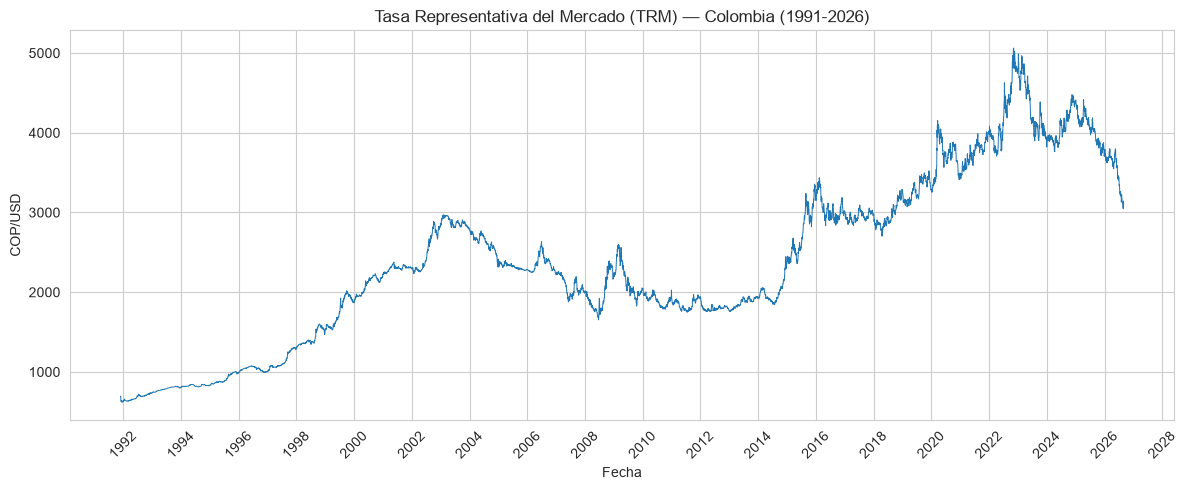

In [5]:
fig, ax = plt.subplots()
ax.plot(trm['fecha'], trm['trm'], color='#1F77B4', linewidth=0.7)
ax.set_title('Tasa Representativa del Mercado (TRM) — Colombia (1991-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('COP/USD')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/01_trm_nivel.png', dpi=150)
plt.show()

**Interpretación:** En la gráfica de la serie podemos observar una tendencia creciente de largo plazo, que parte de un nivel inferior a 1000 COP/USD a comienzos de los años noventa y alcanza un nivel superior a 5000 COP/USD hacia 2023. A pesar de esto, el comportamiento de la serie no es monótono, ya que se identifican episodios de depreciación acelerada seguidos de correcciones.  A pesar de que el gráfico por sí solo no permite determinar causas de los episodios de depreciación, hay algunos episodios documentados en la economía Colombiana que pueden contribuir a la explicación de estos (Banco de la República, s.f.-c), el banco de la república señala eventos como la crisis de las empresas puntocom, la quiebra de Lehman Brothers en 2008, la caída del precio internacional del petróleo en 2014 y la reciente pandemia vivida en 2020 (Banco de la República, s.f.-b), estos episodios y su correspondencia con los tramos de depreciación observados nos permiten construir una hipótesis razonable sobre el origen de los movimientos. Para finalizar, debido a que el nivel de la serie está dominado por su componente tendencial, es de mayor dificultad, identificar otros patrones subyacentes, por lo que es necesario calcular la variación porcentual diaria o retorno diario con la finalidad de remover dicho componente de tendencia. 

In [6]:
# Retorno diario de la TRM
trm['retorno_diario'] = trm['trm'].pct_change()*100

trm.tail(10)

,fecha,trm,retorno_diario
12684,2026-08-19,3098.79,-0.954405
12685,2026-08-20,3053.48,-1.462184
12686,2026-08-21,3062.96,0.310465
12687,2026-08-22,3048.12,-0.484499
12688,2026-08-23,3048.12,0.000000
12689,2026-08-24,3048.12,0.000000
12690,2026-08-25,3056.51,0.275252
12691,2026-08-26,3081.67,0.823161
12692,2026-08-27,3118.24,1.186694
12693,2026-08-28,3144.28,0.835086


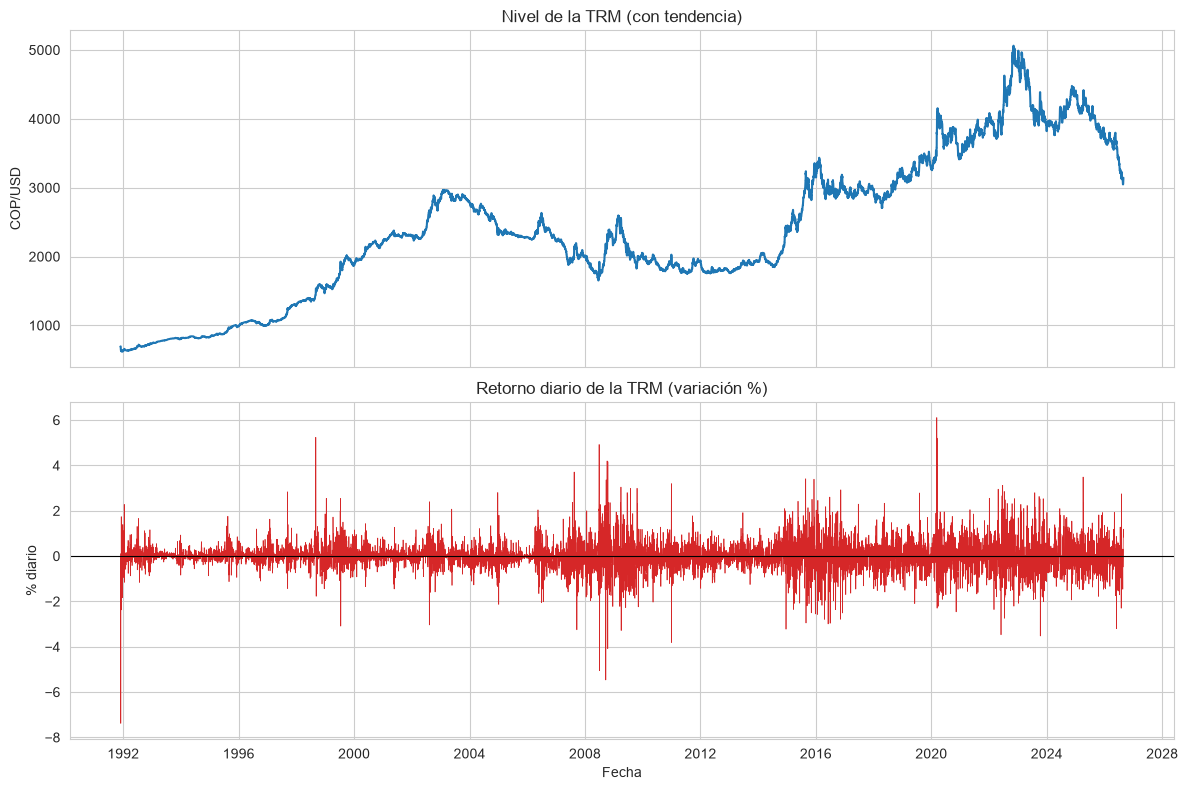

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(trm['fecha'], trm['trm'], color='#1F77B4')
axes[0].set_title('Nivel de la TRM (con tendencia)')
axes[0].set_ylabel('COP/USD')

axes[1].plot(trm['fecha'], trm['retorno_diario'], color='#D62728', linewidth=0.5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Retorno diario de la TRM (variación %)')
axes[1].set_ylabel('% diario')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.savefig("../reports/figures/02_trm_nivel_vs_retorno.png", dpi=150)
plt.show()

**Interpretación:** Observando las dos gráficas podemos concluir que el contraste entre ambos paneles es marcado, por un lado la serie TRM convencional exhibe un desplazamiento sistemático de su media a lo largo del período, mientras que por otro lado, en el panel de retorno diario observamos como este oscila en torno a cero durante toda la serie, con una distribución que pude ser comparable entre los extremos inicial y final, a pesar de esto, en el panel de retorno se observan agrupamientos de alta variabilidad en tramos específicos, como en el año 2020, estos comportamientos consisten en el agrupamiento de volatilidad documentado como propiedad recurrente de las series financieras (Cont, 2001).

---
# 1.2 Análisis gráfico y exploratorio

## 1.2.1 Búsqueda de patrones estacionales

     mediana     Q1     Q3  pct_cero    IQR
mes                                        
1        0.0 -0.079  0.116    38.894  0.195
2        0.0 -0.132  0.103    31.041  0.235
3        0.0 -0.080  0.088    33.548  0.168
4        0.0 -0.151  0.099    33.524  0.250
5        0.0 -0.074  0.134    35.115  0.208
6        0.0 -0.094  0.129    36.190  0.223
7        0.0 -0.116  0.115    34.747  0.231
8        0.0 -0.084  0.182    34.196  0.266
9        0.0 -0.115  0.166    30.784  0.281
10       0.0 -0.119  0.130    33.112  0.249
11       0.0 -0.062  0.090    39.003  0.152
12       0.0 -0.163  0.050    35.207  0.213

Retornos exactamente cero: 4397 de 12693 (34.6%)


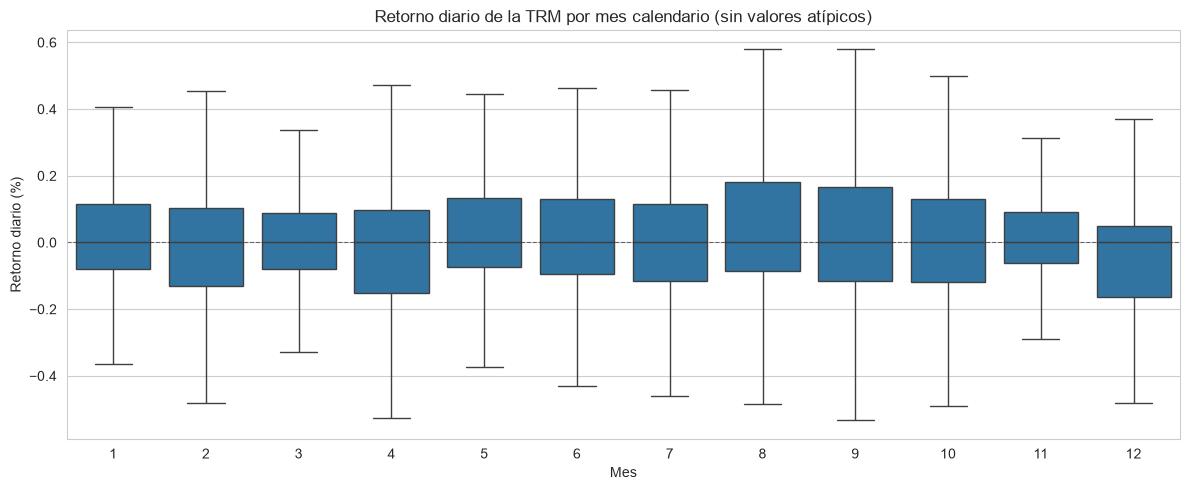

In [8]:
trm['mes'] = trm['fecha'].dt.month
retornos = trm.dropna(subset=['retorno_diario'])

# Resumen numerico por mes
resumen_mes = retornos.groupby('mes')['retorno_diario'].agg(
    mediana='median',
    Q1=lambda s: s.quantile(0.25),
    Q3=lambda s: s.quantile(0.75),
    pct_cero=lambda s: (s==0).mean()*100
).round(3)

resumen_mes['IQR'] = (resumen_mes['Q3'] - resumen_mes['Q1']).round(3)
print(resumen_mes.to_string())

ceros = (retornos['retorno_diario'] == 0).sum()
print(f"\nRetornos exactamente cero: {ceros} de {len(retornos)} ({ceros/len(retornos)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=retornos, x='mes', y='retorno_diario', showfliers=False, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Retorno diario de la TRM por mes calendario (sin valores atípicos)')
ax.set_xlabel('Mes')
ax.set_ylabel('Retorno diario (%)')
plt.tight_layout()
plt.savefig("../reports/figures/03_retorno_por_mes.png", dpi=150)
plt.show()

**Interpretación:** Una vez se ha removido el componente de tendencia se facilita buscar patrones estacionales que antes estaban ocultos, en este caso se hizo uso de boxplot del retorno diario agrupado por mes calendario. En la tabla y en la gráfica podemos observar que la mediana es exactamente cero en los doce meses, mientras que la amplitud de las cajas varia de forma moderadamente 0.152 y 0.281 puntos porcentuales con los extremos en noviembre y septiembre respectivamente, sin que la secuencia siga realmente un patrón de calendario reconocible. Teniendo en cuenta lo anterior, no es posible encontrar evidencia de un efecto calendario mensual en la TRM, siendo esto un resultado que coincide con la ausencia de mecanismos administrativos de periodicidad mensual que puedan inducir estacionalidad en la tasa de cambio. A pesar de esto, el factor de que las medianas sean exactamente cero y no simplemente próximas a cero es un resultado que requiere explicación, ya que en la salida observamos que el 34.6 % de los retornos de la serie vale exactamente cero. Además, con un tercio de la masa concentrada en un valor único, la mediana de cualquier submuestra mensual cae necesariamente en cero independientemente del mes en el cual se esté validando, por lo que estas medianas no aportan información relevante sobre la estacionalidad mensual. Por ende, el origen de esta concentración de ceros puedes derivar del mecanismo de cálculo de la serie, esto debido a que TRM se calcula con base a operaciones registradas por intermediarios del mercado cambiario durante el día hábil inmediatamente anterior, por lo cual para días sábado, domingo y festivo aplica la TRM vigente del día hábil inmediatamente siguiente (Banco de la República, 2018). Esta regla administrativa debería producir un comportamiento diferenciado por día de la semana, verificable empíricamente. 

            mediana     Q1     Q3  pct_cero    IQR
dia_semana                                        
Lunes          0.00  0.000  0.000   100.000  0.000
Martes         0.00 -0.123  0.199    26.751  0.322
Miercoles      0.02 -0.250  0.333     2.372  0.583
Jueves         0.00 -0.285  0.292     2.481  0.577
Viernes        0.00 -0.267  0.276     5.788  0.543
Sabado         0.00 -0.293  0.233     5.185  0.526
Domingo        0.00  0.000  0.000    99.945  0.000


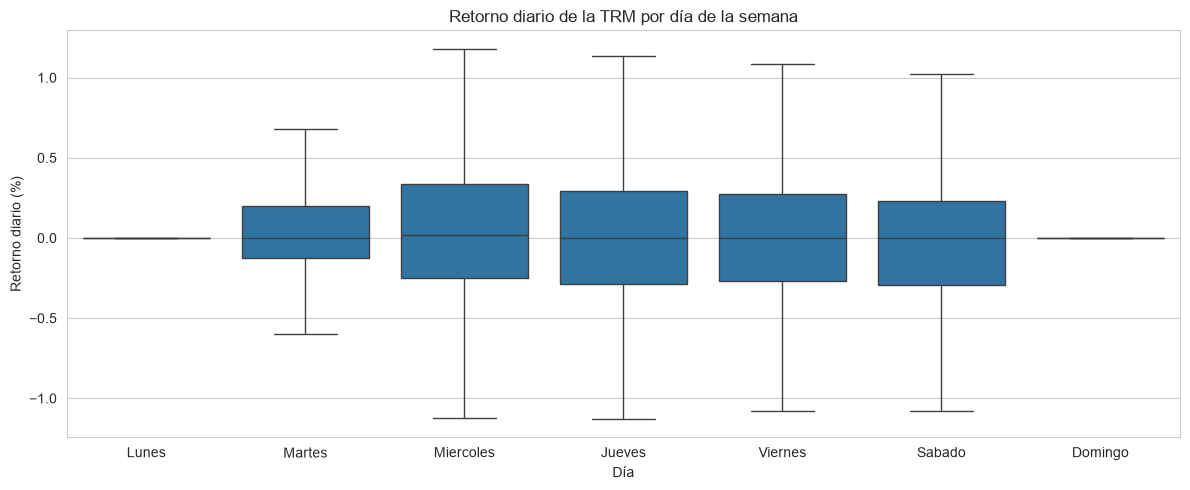

In [9]:
dias_es = {'Monday': 'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miercoles', 'Thursday': 'Jueves', 
           'Friday': 'Viernes', 'Saturday': 'Sabado', 'Sunday': 'Domingo'}
orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

trm['dia_semana'] = trm['fecha'].dt.day_name().map(dias_es)
retornos = trm.dropna(subset=['retorno_diario'])

# Resumen numerico por dia
resumen_dia = retornos.groupby('dia_semana')['retorno_diario'].agg(
    mediana='median',
    Q1=lambda s: s.quantile(0.25),
    Q3=lambda s: s.quantile(0.75),
    pct_cero=lambda s: (s==0).mean()*100,
).reindex(orden_dias).round(3)

resumen_dia['IQR'] = (resumen_dia['Q3'] - resumen_dia['Q1']).round(3)
print(resumen_dia.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=trm.dropna(subset=['retorno_diario']), x='dia_semana', y='retorno_diario',
            order=orden_dias, ax=ax, showfliers=False)
ax.set_title('Retorno diario de la TRM por día de la semana')
ax.set_xlabel('Día')
ax.set_ylabel('Retorno diario (%)')
plt.tight_layout()
plt.savefig('../reports/figures/04_retorno_por_dia_semana.png', dpi=150)
plt.show()

**Interpretación:** Continuando con la idea descrita previamente, en el gráfico de comportamiento por día observamos que la semana no tiene un comportamiento homogéneo. Por un lado, domingo y lunes aparecen como líneas planas, sin cajas ni bigotes visibles, esto debido a que la totalidad de sus retornos se concentran en cero. Por otro lado, el martes presenta caja notoriamente más angosta que el resto, con un rango intercuartílico de 0.322 frente a valores entre 0.526 y 0.583 en los demás días. Finalmente, miércoles, jueves, viernes y sábado muestran distribuciones similares entre sí, centradas en torno a cero.

Los patrones descritos previamente se derivan de la regla de publicación descrita en el análisis de boxplot por mes y no dependen como tal de un comportamiento económico. A partir de esta regla, para sábados, domingos y festivos aplica la TRM vigente del día hábil inmediatamente siguiente  (Banco de la República, 2018), de tal forma que sábado, domingo y lunes comparten el mismo valor, el cual seria el valor certificado para el lunes. Al ser idénticos, los retornos de domingo y lunes resultan nulos por construcción, mientras que la variación que se puede observar el sábado corresponde en realidad al cambio entre dos valores consecutivos de la TRM, lo que se denominaría una jornada completa de negociación. El caso identificado para el martes responde al mismo mecanismo, ya que cuando el lunes es festivo el valor permanece constante un día más, situación que ocurre en el 26.8 % de los martes de la serie y que comprime su rango intercuartílico. Finalmente, esta regularidad detectada es un artefacto de calendario administrativo y no estacionalidad en sentido económico, esta distinción va a condicionar la lectura del componente estacional en secciones posteriores. 


## 1.2.2 Descomposición de la serie

Para la descomposición de la serie se optó por el empleo de un modelo multiplicativo debido a que la amplitud de las fluctuaciones de la serie crece proporcionalmente con su nivel, si se empleara un modelo aditivo se estaría asumiendo que la amplitud es constante, lo cual es un supuesto que la serie no satisface. 

In [10]:
resultado_365 = seasonal_decompose(trm['trm'], model='multiplicative', period=365)
resultado_7 = seasonal_decompose(trm['trm'], model='multiplicative', period=7)

print(f"Rango estacional period=365: {resultado_365.seasonal.min():.4f} a {resultado_365.seasonal.max():.4f}")
print(f"Rango estacional peroid=7: {resultado_7.seasonal.min():.4f} a {resultado_7.seasonal.max():.4f}")

# Numero de observaciones promediadas para estimar cada indice estacional

print()
for periodo, resultado in [(365, resultado_365), (7, resultado_7)]: 
    sin_tendencia = (trm['trm'] / resultado.trend).dropna()
    obs_por_indice = sin_tendencia.groupby(sin_tendencia.index % periodo).size()
    print(f"Periodo {periodo:>3}: {len(trm) // periodo:>5} ciclos completos | "
          f"{obs_por_indice.min()}-{obs_por_indice.max()} observaciones por índice estacional")

Rango estacional period=365: 0.9794 a 1.0162
Rango estacional peroid=7: 0.9996 a 1.0004

Periodo 365:    34 ciclos completos | 33-34 observaciones por índice estacional
Periodo   7:  1813 ciclos completos | 1812-1813 observaciones por índice estacional


**Interpretación:** Para dar continuidad a lo mencionado previamente, en la salida podemos observar que el componente estacional estimado con periodo 365 abarca un rango considerablemente más amplio que estimado con período 7. A pesar de esto, una mayor amplitud no valida por si sola la elección del periodo, ya que el criterio que adopto para este trabajo se apoya en cuantas repeticiones por ciclo quedan disponibles para realizar la estimación. Para validar lo mencionado previamente se hizo uso de saesonal_decompose que calcula cada índice estacional promediando las observaciones sin tendencias que ocupan la misma posición dentro del ciclo, a partir de esto se obtuvo que para el periodo 7 cada índice resulta del promedio de hasta unas 1813 observaciones, mientras que con periodo 365 se promedian apenas 34, lo que es equiparable a una relación cercana a 53 a 1. Por otro lado, con tan pocas repeticiones el promedio no alcanza a estabilizarse y el componente resultante recoge en gran parte el ruido de estimación y no un patrón real anual. Finalmente, a esto se suma el ciclo semanal el cual cuenta como un mecanismo documentado, que es la regla de publicación verificada en secciones previas mientras que para un ciclo anual no se identifica ningún mecanismo equivalente en una tasa de cambio de libre flotación, por lo que se opta por el periodo 7. 

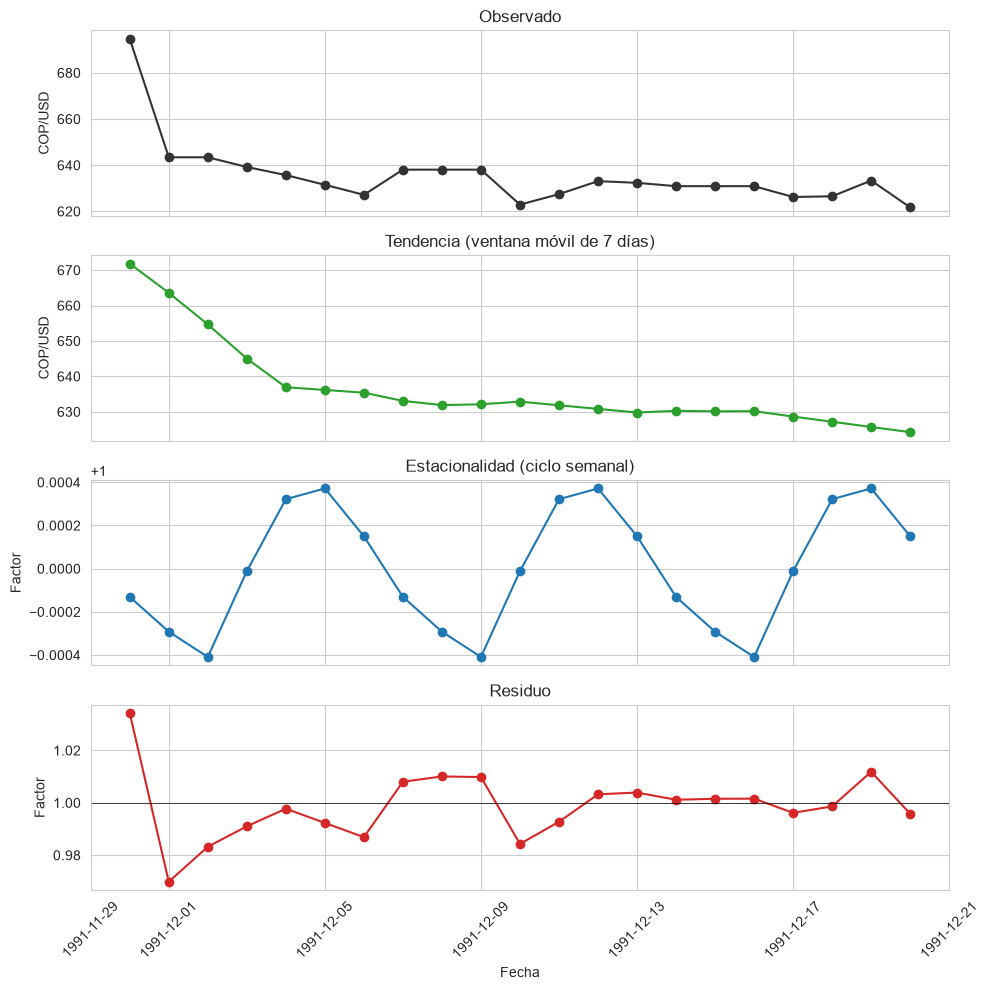

In [11]:
# Zoom a 3 semanas para ver la forma real del ciclo semanal
ventana = slice(3, 24)
fechas_zoom = trm['fecha'].iloc[ventana]

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axes[0].plot(fechas_zoom, trm['trm'].iloc[ventana], color='#333333', marker='o')
axes[0].set_title('Observado')
axes[0].set_ylabel('COP/USD')

axes[1].plot(fechas_zoom, resultado_7.trend.iloc[ventana], color='#2CA02C', marker='o')
axes[1].set_title('Tendencia (ventana móvil de 7 días)')
axes[1].set_ylabel('COP/USD')

axes[2].plot(fechas_zoom, resultado_7.seasonal.iloc[ventana], color='#1F77B4', marker='o')
axes[2].set_title('Estacionalidad (ciclo semanal)')
axes[2].set_ylabel('Factor')

axes[3].plot(fechas_zoom, resultado_7.resid.iloc[ventana], color='#D62728', marker='o')
axes[3].axhline(1, color='black', linewidth=0.5)
axes[3].set_title('Residuo')
axes[3].set_ylabel('Factor')
axes[3].set_xlabel('Fecha')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/05_descomposicion_zoom.png", dpi=150)
plt.show()

**Interpretación:** Una vez definido el modelo y el período, en la gráfica de descomposición podemos observar el comportamiento de cada uno de los componentes. Por un lado, el componente de tendencia reproduce casi exactamente la trayectoria del primer panel de observación, lo que nos permite determinar que una ventana móvil de 7 días resulta insuficiente para estimar una tendencia de largo plazo, por ende, para este propósito el gráfico de la sección 1.1 es la referencia adecuada y el aporte de esta descomposición por periodo móvil se concentra en los paneles restantes. 

Por otro lado, si observamos el componente estacional podemos determinar que este presenta un ciclo regular de 7 días, con una forma definida y de repetición contante, con una amplitud que se mantiene en un rango de ±0.04 % aproximadamente, magnitud que resulta muy inferior a las de las variaciones diarias observadas en el panel de retorno de la sección 1.1, las cuales alcanzan varios puntos porcentuales. Para finalizar, el componente residual fluctúa en torno a la unidad si una estructura aparente dentro de la ventana examinada. Tendiendo en cuenta lo previamente mencionado, podemos concluir que la variabilidad de la serie se concentra en el componente irregular, ya que el componente estacional, a pesar de ser sistemático, des de una magnitud marginal frente a los movimientos diarios.

# 1.2.3 Detección de outliers

Para la detección de Outliers se hizo uso de la regla del rango intercuartílico (IQR) propuesta por Tukey (1977), la cual se aplicó sobre el retorno diario y no sobre el nivel de la serie, debido a que en una serie con tendencia sostenida la regla de IQR no identifica comportamientos anómalos sino la posición de la serie dentro de su propia trayectoria, lo que se puede verificar aplicándola sobre el nivel, donde de las 12694 observaciones únicamente 32 resultan marcadas y la totalidad de estas se concentra entre octubre de 2022 y febrero de 2023, es decir, dentro de la ventana de máximo histórico. Por lo tanto, lo que la regla detecta es ese caso es el pico de la tendencia y no un comportamiento atípico, razón por la cual se opta por aplicarla sobre el retorno diario, que es la serie a la que previamente se le removió dicho componente. 

In [14]:
# Verificación previa: la regla IQR sobre el nivel detecta la posición dentro de
# la tendencia y no comportamientos anomalos

q1_nivel = trm['trm'].quantile(0.25)
q3_nivel = trm['trm'].quantile(0.75)
iqr_nivel = q3_nivel - q1_nivel
lim_inf_nivel = q1_nivel - 1.5 * iqr_nivel
lim_sup_nivel = q3_nivel + 1.5 * iqr_nivel
atipicos_nivel = (trm['trm'] <  lim_inf_nivel) | (trm['trm'] > lim_sup_nivel)
print(f"Sobre el nivel: {atipicos_nivel.sum()} observaciones marcadas "
      f"({atipicos_nivel.mean()*100:.2f}%)")
print(f"Fechas marcadas: {trm.loc[atipicos_nivel, 'fecha'].min().date()} a "
      f"{trm.loc[atipicos_nivel, 'fecha'].max().date()}\n")

# Aplicación sobre el retorno diario
q1 = trm['retorno_diario'].quantile(0.25)
q3 = trm['retorno_diario'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

trm['outlier'] = (trm['retorno_diario'] < lim_inf) | (trm['retorno_diario'] > lim_sup)

n_outliers = trm['outlier'].sum()
n_total = trm['retorno_diario'].notna().sum()

print(f"Limite inferior: {lim_inf:.3f}% | Limite superior: {lim_sup:.3f}%")
print(f"Outliers detectados: {n_outliers} de {n_total} ({n_outliers/n_total*100:.2f}%)")
print(f"Curtosis del retorno diario: {trm['retorno_diario'].kurtosis():.2f} (una distribución normal tiene 0)")

Sobre el nivel: 32 observaciones marcadas (0.25%)
Fechas marcadas: 2022-10-22 a 2023-02-23

Limite inferior: -0.439% | Limite superior: 0.449%
Outliers detectados: 3021 de 12693 (23.80%)
Curtosis del retorno diario: 13.61 (una distribución normal tiene 0)


**Interpretación:** A partir de los resultados, podemos observar que la regla de IQR clasifica como atípico el 23.80 % de las observaciones, esta proporción es muy superior con respecto a lo que se espera de una distribución normal. A partir de esto, la curtosis calculada nos permite explicar este resultado, ya que un valor de 13.61 frente al 0 de una distribución normal nos indica que la distribución del retorno diario presenta colas considerablemente más pesadas. Este comportamiento leptocúrtico fue sistematizado como uno de los hechos estilizados de los retornos financieros (Cont, 2001), por lo que esta proporción obtenida de Outliers se interpreta como evidencia de colas pesadas y no como un problema de calidad de los datos, razón por la cual las observaciones identificadas no se eliminan de la serie. 

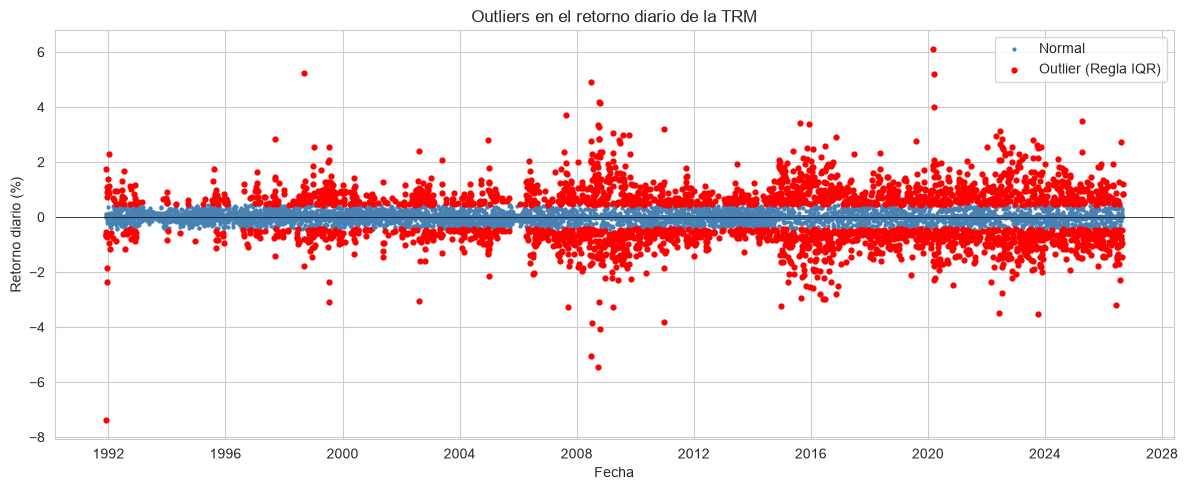

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(trm['fecha'], trm['retorno_diario'], s=4, color='steelblue', label='Normal')
ax.scatter(trm.loc[trm['outlier'], 'fecha'], trm.loc[trm['outlier'], 'retorno_diario'],
           s=12, color='red', label='Outlier (Regla IQR)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Outliers en el retorno diario de la TRM')
ax.set_xlabel('Fecha')
ax.set_ylabel('Retorno diario (%)')
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/06_outliers_retorno.png", dpi=150)
plt.show()

In [17]:
# Distribución temporal de los atípicos. El umbral IQR es único para toda la 
# serie, por lo que conviene revisar si los marcados se reparten de forma pareja

trm['año'] = trm['fecha'].dt.year
prop_anual = trm.groupby('año')['outlier'].mean() * 100

print("Años con mayor proporción de atípicos:")
print(prop_anual.nlargest(5).round(1).to_string())
print ("\nAños con menor proporción de atípicos:")
print(prop_anual.nsmallest(5).round(1).to_string())

# Contraste entre regimenes cambiarios: la banda cambiaria rigio hasta el
# 25 de septiembre de 1999, fecha de la cual la tasa flota libremente

corte = pd.Timestamp('1999-09-25')
banda = trm[trm['fecha'] < corte]
flotacion = trm[trm['fecha'] >= corte]

print(f"\nBanda cambiaria: {banda['outlier'].mean()*100:.1f}% atípicos | desv. est. del retorno {banda['retorno_diario'].std():.3f}")
print(f"Libre flotación: {flotacion['outlier'].mean()*100:.1f}% atípicos | desv. est. del retorno {flotacion['retorno_diario'].std():.3f}")

Años con mayor proporción de atípicos:
año
2015    46.6
2008    42.3
2016    41.8
2022    41.1
2023    40.8

Años con menor proporción de atípicos:
año
1993    1.6
1994    2.5
1996    4.4
2001    5.8
1995    7.7

Banda cambiaria: 10.6% atípicos | desv. est. del retorno 0.368
Libre flotación: 27.6% atípicos | desv. est. del retorno 0.591



**Interpretación:** A partir de los resultados podemos determinar que los valores atípicos no se distribuyen uniformemente con el paso del tiempo, estos resultados no corresponden a resultados aislados sino a un aumento sostenido a lo largo de la serie. Adicionalmente, a pesar de que el gráfico por si solo no nos permite determinar la causa de este comportamiento, el contraste por régimen cambiario nos ofrece una explicación razonable, esto ya que Colombia mantuvo un sistema de banda cambiaria hasta el 25 de septiembre de 1999, fecha desde la cual la tasa de cambio paso a flotar libremente (Banco de la República, s.f.-d). Bajo el régimen de banda la autoridad intervenía para mantener la tasa dentro de unos límites, por ende, la variabilidad diaria era estructuralmente menor, lo que se refleja en la salida con un 10.6 % de atípicos y una desviación estándar del retorno de 0.368 frente al 27.6 % y 0.591 del periodo de libre flotación, es decir, una volatilidad 1.60 veces mayor. Teniendo en cuenta lo anterior, podemos concluir que al aplicar un umbral único sobre la serie cuyo régimen de volatilidad cambió a mitad de periodo, genera que la regla identifique en buena medida el cambio de régimen y no observaciones anómalas individuales, esta es una limitación que conviene tener presente al interpretar la proporción obtenida. 

---
# 1.3 Estacionariedad

Retomando lo evidenciado en las secciones anteriores, tanto el nivel como la dispersión de la serie cambian a lo largo del periodo, por lo que corresponde evaluar formalmente si la serie es estacionaria. Para realizar estas pruebas se hizo uso de log-retorno, el cual corresponde a la primera diferencia del logaritmo de la serie, más no a la variación porcentual simple calculada en la sección 1.1. Para justificar esto hacemos uso de la hipótesis de caminata aleatoria que se asocia a la eficiencia de marcado (Fama, 1979), según la cual el precio de un activo en un mercado eficiente sigue un proceso de la forma log(P_t) = Log(P_t-1) + e_t, donde e_t corresponde a un término de ruido blanco. Teniendo esto en cuenta el nivel es no estacionario por construcción, ya que constituye una suma acumulada de choques, mientras que su primera diferencia sí satisface las condiciones de estacionariedad débil, además, el Log-retorno es aditivo en el tiempo, propiedad que la variación porcentual simple no posee. 

In [ ]:
log_trm = np.log(trm['trm'])
trm['log_retorno'] = log_trm.diff()*100

comparacion = trm[['fecha', 'retorno_diario', 'log_retorno']].dropna()
print("Día de mayor movimiento absoluto:")
print(comparacion.loc[comparacion['retorno_diario'].abs().idxmax()])
print("\nUn día típico (movimiento pequeño):")
print(comparacion.iloc[100])

Día de mayor movimiento absoluto:
fecha             1991-12-01 00:00:00
retorno_diario              -7.381604
log_retorno                  -7.66824
Name: 4, dtype: object

Un día típico (movimiento pequeño):
fecha             1992-03-07 00:00:00
retorno_diario              -0.080097
log_retorno                 -0.080129
Name: 101, dtype: object


**Interpretación:** E	n los resultados se pude observar que en jornadas de variación reducida ambas medidas resultan prácticamente equivalentes, con diferencias inferiores a una milésima porcentual, mientras que, en la observación de mayor movimiento absoluto, la divergencia es apreciable, con -7.38 % frente a -7.67%. Lo anterior es debido a que que la aproximación entre ambas se deteriora a medida que aumenta la magnitud del cambio, razón por la cual se trabaja con Log-retorno en las pruebas que siguen. 

### Media y desviación móvil

Previo a realizar las pruebas formales se hizo uso de una ventana móvil de 365 observaciones para inspeccionar la media y la desviación estándar en la serie, con la finalidad de evaluar de forma visual las dos primeras condiciones de estacionariedad débil, es decir, que la media y la varianza se mantengan constantes en el tiempo.

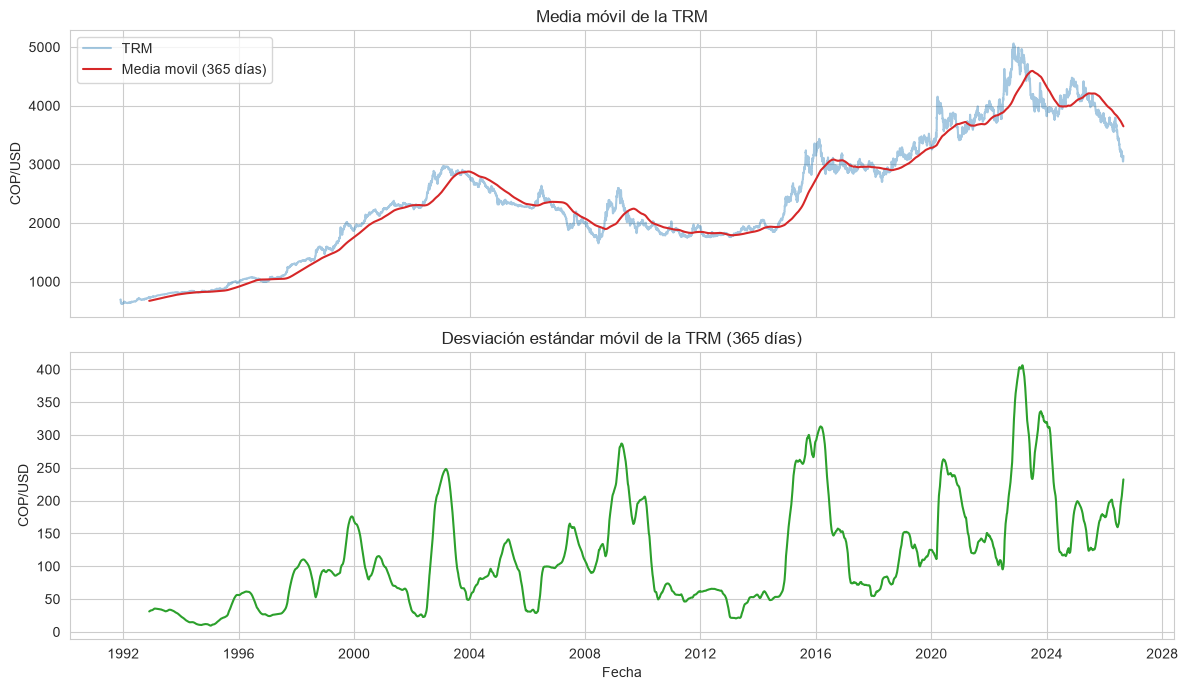

In [ ]:
media_movil = trm['trm'].rolling(window=365).mean()
std_movil = trm['trm'].rolling(window=365).std()

fig, axes = plt.subplots(2,1, figsize=(12, 7), sharex=True)
axes[0].plot(trm['fecha'], trm['trm'], color='#1F77B4', alpha=0.4, label='TRM')
axes[0].plot(trm['fecha'], media_movil, color='#D62728', label='Media movil (365 días)')
axes[0].set_title('Media móvil de la TRM')
axes[0].set_ylabel('COP/USD')
axes[0].legend()

axes[1].plot(trm['fecha'], std_movil, color='#2CA02C')
axes[1].set_title('Desviación estándar móvil de la TRM (365 días)')
axes[1].set_ylabel('COP/USD')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.savefig('../reports/figures/07_rolling_mean_std.png', dpi=150)
plt.show()

**Interpretación:** En el panel superior de la gráfica se pude observar que la media móvil reproduce la trayectoria de la serie en lugar de mantenerse constante, esto constituye evidencia directa del incumplimiento de la primera condición de estacionariedad débil. Por otro lado, en el panel inferior de la gráfica la desviación estándar móvil tampoco es constante, ya que en esta se pueden observar máximos locales con valores que oscilan aproximadamente entre 10 y 400 COP/USD, a partir de esto podemos concluir que ambos resultados permiten rechazar la hipótesis de estacionariedad en las pruebas formales que se aplican en las siguientes secciones. 

### Pruebas formales: ADF y KPSS

Para implementar estas pruebas, se hizo a partir de funciones dado que se aplican en tres etapas sucesivas sobre el nivel, el logaritmo y la primera diferencia del logaritmo. Se debe tener en cuenta que ambas pruebas plantean hipótesis nulas puestas, por un lado la prueba de Dickey-Fuller aumentada evalúa la presencia de una raíz unitaria como hipótesis nula, de tal forma que un p-valor inferior a 0.05 permite concluir estacionariedad (Dickey & Fuller, 1979), mientras que la prueba KPSS invierte el planteamiento y toma la estacionariedad como hipótesis nula, teniendo esto en cuenta un p-valor inferior a 0.05 indica lo contrario (Kwiatkowski et al., 1992). La aplicación conjunta de estos métodos reduce el riesgo de conclusiones erróneas derivadas de la baja potencia de cada prueba de forma aislada. 

In [ ]:
def prueba_adf(serie, nombre):
    resultado = adfuller(serie.dropna())
    print(f"---ADF: {nombre}---")
    print(f"Estadistico: {resultado[0]:.4f} | p-valor: {resultado[1]:.4f}")
    conclusion = 'Estacionaria (rechaza H0)' if resultado[1] < 0.05 else 'No estacionaria (no rechaza H0)'
    print(f"Conclusión: {conclusion}")
    print()

def prueba_kpss(serie, nombre): 
    resultado = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f"---KPSS: {nombre}---")
    print(f"Estadistico: {resultado[0]:.4f} | p-valor: {resultado[1]:.4f}")
    conclusion = 'Estacionaria (no rechaza H0)' if resultado[1] >=0.05 else 'No estacionaria (rechaza H0)'
    print(f"Conclusión: {conclusion}")
    print()

In [ ]:
prueba_adf(trm['trm'], 'TRM (nivel)')
prueba_kpss(trm['trm'], 'TRM (nivel)')

---ADF: TRM (nivel)---
Estadistico: -1.5661 | p-valor: 0.5006
Conclusión: No estacionaria (no rechaza H0)

---KPSS: TRM (nivel)---
Estadistico: 13.5358 | p-valor: 0.0100
Conclusión: No estacionaria (rechaza H0)



**Interpretación:** En la salida observamos que ambas pruebas coinciden al clasificar la serie en nivel como no estacionaria, ya que la prueba ADF no rechaza la hipótesis nula de raíz unitaria con un p-valor de 0.5006, mientras que KPSS rechaza la hipótesis nula de estacionariedad con un p-valor de 0.01. La convergencia de ambos permite confirmar lo evidenciado previamente en el análisis gráfico. 

In [ ]:
prueba_adf(log_trm, 'log(TRM)')
prueba_kpss(log_trm, 'log(TRM)')

---ADF: log(TRM)---
Estadistico: -2.6129 | p-valor: 0.0904
Conclusión: No estacionaria (no rechaza H0)

---KPSS: log(TRM)---
Estadistico: 13.1370 | p-valor: 0.0100
Conclusión: No estacionaria (rechaza H0)



**Interpretación:** Podemos observar con los resultados que la transformación logarítmica no modifica la conclusión, ya que ambas pruebas mantienen el diagnóstico de no estacionariedad. Esto se debe a que el logaritmo estabiliza la varianza al comprimir proporcionalmente las variaciones de mayor magnitud, pero no elimina el componente tendencial, que es la fuente principal del incumplimiento de las condiciones de estacionariedad en esta serie. 

In [ ]:
prueba_adf(trm['log_retorno'], 'Log-retorno de TRM')
prueba_kpss(trm['log_retorno'], 'Log-retorno de TRM')

---ADF: Log-retorno de TRM---
Estadistico: -20.3830 | p-valor: 0.0000
Conclusión: Estacionaria (rechaza H0)

---KPSS: Log-retorno de TRM---
Estadistico: 0.4163 | p-valor: 0.0701
Conclusión: Estacionaria (no rechaza H0)



**Interpretación:** Podemos observar como al aplicar una única diferencia sobre la serie logarítmica, en la salida ambas coinciden esta vez en no rechazar la estacionalidad con un p-valor de 0.0000 en ADF y de 0.0701 en KPSS. El resultado es consistente con la hipótesis de caminata aleatoria descrita previamente (Fama, 1970), bajo la cual un precio de mercado se caracteriza como un proceso integrado de orden uno. 

---
# 1.4 Funciones de autocorrelación (ACF y PACF)

Teniendo en cuenta la transformación que permite volver la serie estacionaria, solo hace falta verificar el resultado mediante las funciones de autocorrelación. Por un lado, la función de autocorrelación mide la correlación entre la serie y sus rezagos incluyendo los efectos que se transmiten a través de rezagos intermedios, mientras que por otro lado la función de autocorrelación parcial aísla la correlación directo al controlar los efectos de los rezagos. En este caso no se replica el análisis sobre el logaritmo de la serie de forma independiente, ya que su ACF coincide con la de la serie en nivel hasta la cuarta cifra decimal, por lo que se contrastan únicamente el nivel y el log-retorno. 

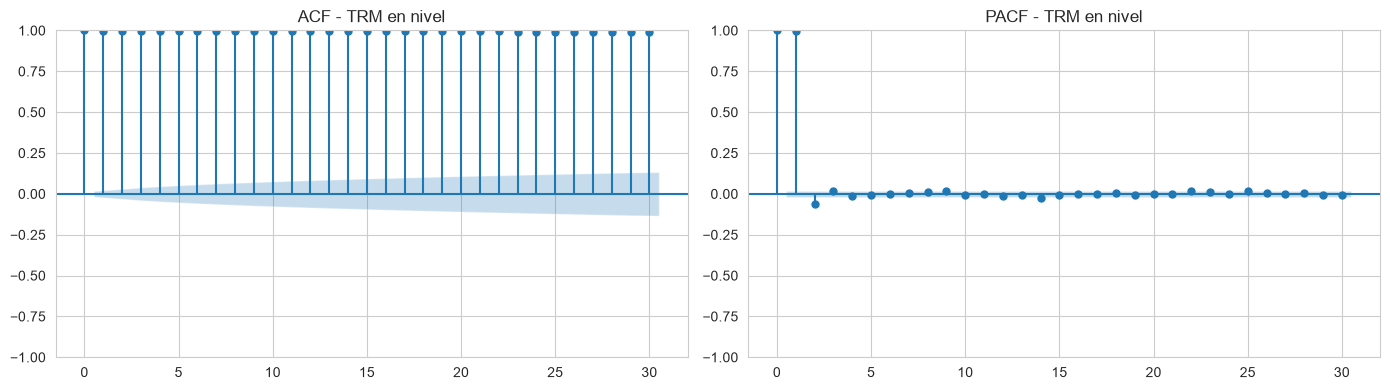

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(trm['trm'], lags=30, ax=axes[0])
axes[0].set_title('ACF - TRM en nivel')
plot_pacf(trm['trm'], lags=30, ax=axes[1])
axes[1].set_title('PACF - TRM en nivel')
plt.tight_layout()
plt.savefig("../reports/figures/08_acf_pacf_nivel.png", dpi=150)
plt.show()

**Interpretación:** En el gráfico logramos observar que la ACF no decae dentro de los treinta rezagos considerados y se mantiene próxima a la unidad en todo el rango, este comportamiento es característico de una serie no estacionaria (Box et al., 2015). Por otro lado, la PACF presenta un único coeficiente significativo en el primer rezago, con valores cercanos a cero en los rezagos posteriores, esta configuración es propia de un proceso autorregresivo de primer orden con coeficiente próximo a uno, es decir, una caminata aleatoria. 

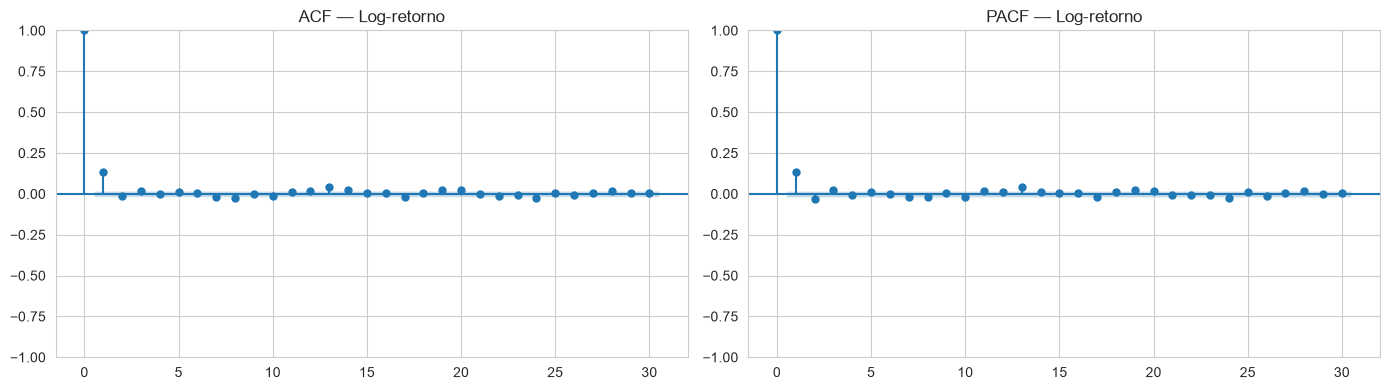

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(trm['log_retorno'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF — Log-retorno')
plot_pacf(trm['log_retorno'].dropna(), lags=30, ax=axes[1])
axes[1].set_title('PACF — Log-retorno')
plt.tight_layout()
plt.savefig('../reports/figures/09_acf_pacf_retorno.png', dpi=150)
plt.show()

**Interpretación:** En este caso tanto ACF como PACF decaen a valores próximos a cero inmediatamente después del primer rezago, sin coeficientes sistemáticamente significativos en los rezagos posteriores, esto debido a que el comportamiento se aproxima al de un proceso de ruido blanco, el cual es un resultado esperado bajo la hipótesis de eficiencia de mercado (Fama, 1970) y consistente con la ausencia de autocorrelación lineal reportada como hecho estilizado de los retornos financieros (Cont, 2001). Adicionalmente, en los rezagos 7, 14, 21 y 28, donde se esperaría encontrar la huella del ciclo semanal identificado previamente, no se observan coeficientes diferenciables del resto, lo cual confirma que dicho ciclo obedece a la regla de la publicación de la serie y no a una estructura de dependencia temporal aprovechable.  Finalmente, el contraste entre ambos gráficos sintetiza el resultado central del análisis, ya que la TRM en nivel constituye una serie no estacionaria mientras que su primera diferencia logarítmica sí satisface las condiciones de estacionalidad débil. 

---
# Referencias

Banco de la República. (2018). *Circular Reglamentaria Externa DODM-146. Asunto 8: Metodología de cálculo de la tasa de cambio representativa del mercado*. https://www.banrep.gov.co/sites/default/files/reglamentacion/archivos/dodm146-25052018.pdf

Banco de la República. (s.f.-a). *Tasa de cambio o tasa de cambio representativa del mercado (TRM)* [Glosario]. Recuperado el 30 de agosto de 2026, de https://www.banrep.gov.co/es/glosario/tasa-cambio-trm

Banco de la República. (s.f.-b). *Box 1: Recent performance of the exchange rate in Colombia*. Inflation Report. Recuperado el 30 de agosto de 2026, de https://www.banrep.gov.co/en/publications/inflation-report/box-1-recent-performance-of-the-exchange-rate-in-colombia

Banco de la República. (s.f.-c). *Pass-through of the exchange rate to core inflation in Colombia: An analysis of time-varying parameters*. Recuperado el 30 de agosto de 2026, de https://www.banrep.gov.co/en/pass-through-exchange-rate-core-inflation-colombia-analysis-time-varying-parameters

Banco de la República. (2026). *Tasa Representativa del Mercado (TRM). Serie diaria 1991-2026* [Conjunto de datos]. Portal de Estadísticas Económicas. https://suameca.banrep.gov.co/estadisticas-economicas/

Banco de la República. (s.f.-d). *Banda cambiaria* [Enciclopedia]. Red Cultural del Banco de la República. Recuperado el 31 de agosto de 2026, de https://enciclopedia.banrepcultural.org/index.php/Banda_cambiaria

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5.ª ed.). Wiley.

Cont, R. (2001). Empirical properties of asset returns: Stylized facts and statistical issues. *Quantitative Finance, 1*(2), 223-236.

Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *Journal of the American Statistical Association, 74*(366), 427-431.

Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. *The Journal of Finance, 25*(2), 383-417.

Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992). Testing the null hypothesis of stationarity against the alternative of a unit root: How sure are we that economic time series have a unit root? *Journal of Econometrics, 54*(1-3), 159-178.

Mandelbrot, B. (1963). The variation of certain speculative prices. *The Journal of Business, 36*(4), 394-419.

Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92-96.

Superintendencia Financiera de Colombia. (s.f.). *Tasa de Cambio Representativa del Mercado - TRM*. Recuperado el 30 de agosto de 2026, de https://www.superfinanciera.gov.co/publicaciones/60819/